
Processing: GSM4089151_P1_gene_cell_exprs_table
Transposed matrix shape: (3961, 23428)
Number of gene symbols: 23428
Number of cell names: 3961


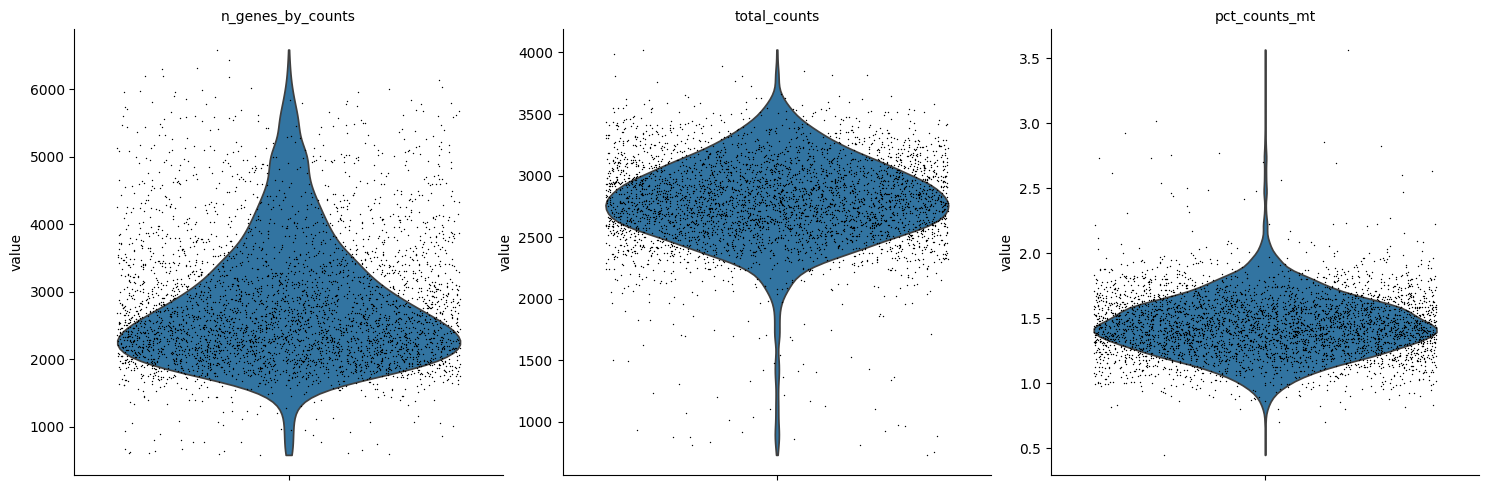

None


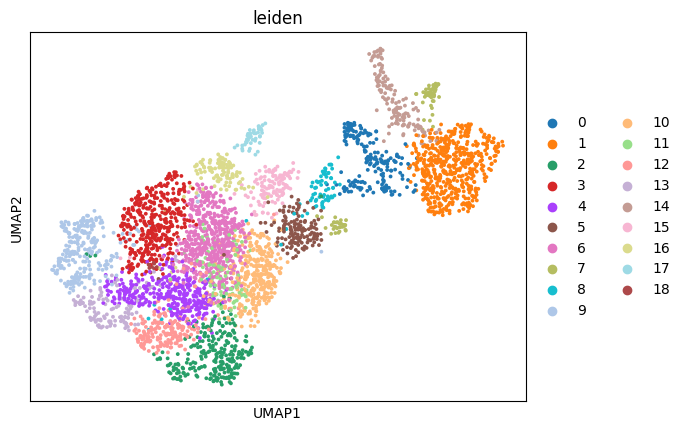

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

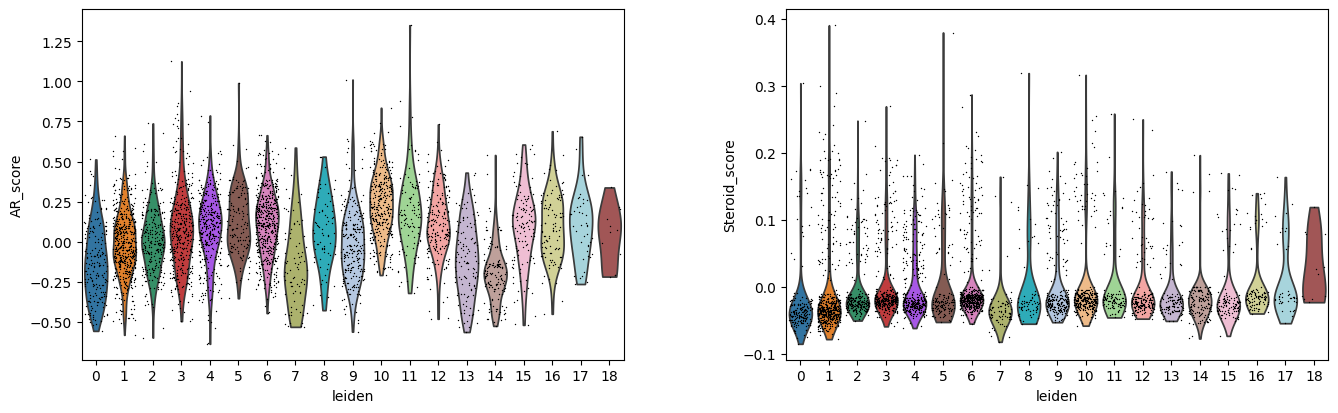

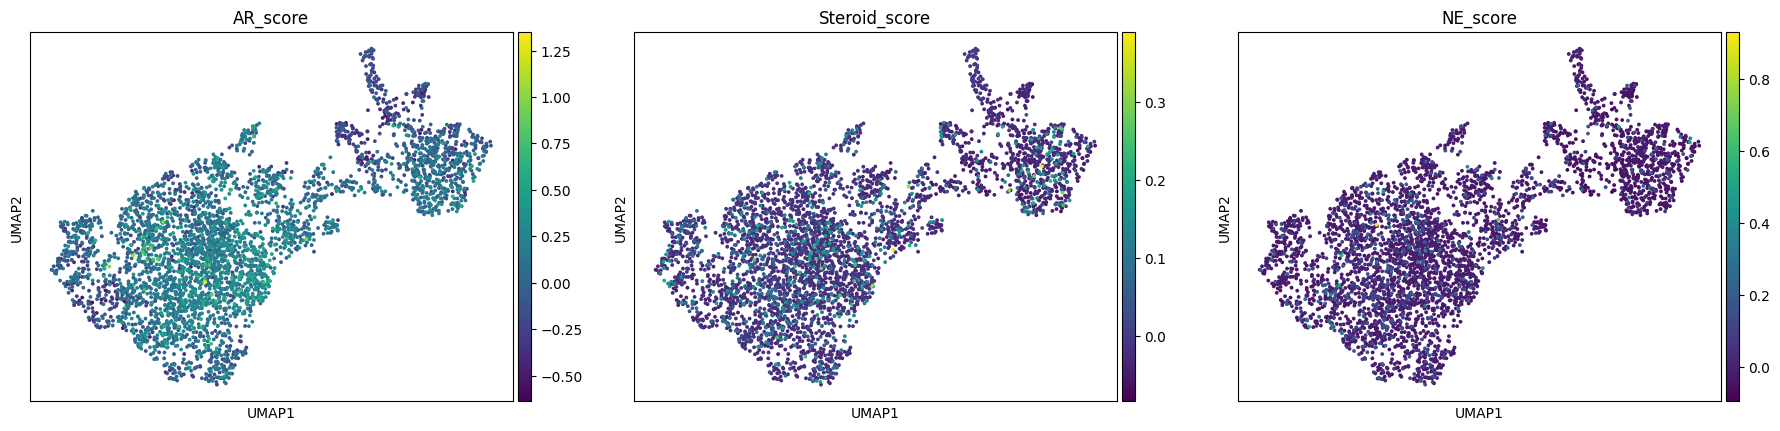

AttributeError: type object 'Model' has no attribute 'from_pretrained'

In [6]:
import scanpy as sc 
import pandas as pd 
import glob, os 
import gseapy as gp 
import celltypist
from celltypist import models

input_dir = "./single_cell_references/"
output_dir = "./h5ad_out/" 
os.makedirs(output_dir, exist_ok=True)

for txt_path in glob.glob(os.path.join(input_dir, "*.txt")): 
    sample = os.path.basename(txt_path).replace(".txt", "")
    print(f"\nProcessing: {sample}") 
    # Read TXT
    df = pd.read_csv(txt_path, sep="\t", engine="python", index_col=0) 
    # Extract gene symbols and cell names 
    gene_symbols = df.iloc[:, 0].astype(str).values 
    cell_names = df.columns[1:].astype(str) # Extract count matrix
    counts = df.iloc[:, 1:].values # Transpose: cells as rows, genes as columns 
    counts = counts.T 
    print("Transposed matrix shape:", counts.shape) # (n_cells, n_genes) 
    print("Number of gene symbols:", len(gene_symbols))
    print("Number of cell names:", len(cell_names)) 
    # Build AnnData
    adata = sc.AnnData(X=counts) 
    adata.var_names = gene_symbols 
    adata.obs_names = cell_names 
    adata.var_names_make_unique() 
    
    sc.pp.filter_cells(adata, min_counts=500) # remove low-count cells 
    sc.pp.filter_genes(adata, min_cells=5) 
    sc.pp.normalize_total(adata) 
    sc.pp.log1p(adata) # log-transform # 3. store raw counts 
    adata.raw = adata # mitochondrial genes, "MT-" for human, "Mt-" for mouse 
    adata.var["mt"] = adata.var_names.str.startswith("MT-") # ribosomal genes 
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL")) # hemoglobin genes 
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]") #preprocessing_qc(adata) 
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True) 
    
    adata = adata[adata.obs["pct_counts_mt"] < 25, :] 
    
    print(sc.pl.violin( adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True, )) 
    
    ar_genes = ["KLK3", "NKX3-1", "TMPRSS2", "FKBP5", "PMEPA1", "AR"] 
    
    steroid_genes = ["HSD17B2", "CYP17A1", "SRD5A2", "STAR", "CYP11A1", "HSD3B1", "HSD17B1"]
    
    NE_genes = ["CHGA", "SYP", "ENO2", "ASCL1"]
    
    sc.tl.score_genes(adata, gene_list=NE_genes, score_name="NE_score") 
    sc.tl.score_genes(adata, gene_list=ar_genes, score_name="AR_score") 
    
    sc.tl.score_genes(adata, gene_list=steroid_genes, score_name="Steroid_score") #clustering and visualization
    
    sc.pp.pca(adata, n_comps=50) 
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30) 
    sc.tl.leiden(adata, flavor="igraph", n_iterations=-1) 
    sc.tl.umap(adata) 
    sc.pl.umap(adata, color=["leiden"]) 
    sc.pl.violin(adata, ["AR_score", "Steroid_score"], groupby="leiden", jitter=0.4) 
    
    sc.pl.umap(adata, color=["AR_score", "Steroid_score", "NE_score"]) 
    
    model = celltypist.models.Model.from_pretrained('Human_All_Low') 
    
    predictions = celltypist.annotate(adata, model=model, majority_voting=True) 
    
    adata.obs['CellTypist_label'] = predictions.predicted_labels 
    adata.obs['CellTypist_prob'] = predictions.predicted_probabilities.max(axis=1) 
    
    sc.pl.umap(adata, color='CellTypist_label', legend_loc='on data', frameon=False, size=20) 
    # Save 
    out_path = os.path.join(output_dir, f"{sample}.h5ad")
    print(" → Writing:", out_path) 
    adata.write_h5ad(out_path)

In [ ]:


adatas = {}
for filepath in glob.glob(os.path.join(basedir, "*.h5ad")):
    sample_name = os.path.basename(filepath).replace(".h5ad", "")
    adatas[sample_name] = sc.read_h5ad(filepath)    

In [ ]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata